# Dataset (https://www.kaggle.com/datasets/kazanova/sentiment140)

* https://www.youtube.com/watch?v=mY-lIkjrvzI&list=PL049bGjkT7dIARLPrxvA4-tbEcg6k0UDX&index=123

In [ ]:
patience=2
epochs=999

In [1]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [2]:
folder = '/gdrive/MyDrive/data/'

In [3]:
!ls '/gdrive/MyDrive/data/'

births.csv	   exemple.txt				     WASTE_COURT.zip
births_github.csv  Synthetic_Financial_datasets_log.csv.zip  WASTE.zip
decades.csv	   tweets.csv


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(folder + "tweets.csv", encoding="latin", header=None)

In [6]:
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [7]:
df = df.iloc[:,[0, 5]]

In [8]:
df.head()

,0,5
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [9]:
df.columns = ['sentiment', 'tweet']

In [10]:
df.head()

,sentiment,tweet
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [11]:
df['sentiment'].value_counts()

,count
sentiment,
0,800000
4,800000


In [12]:
sents = {0:"negatif", 4:"positif"}

In [13]:
sents[0]

'negatif'

In [14]:
df['sentiment'] = df['sentiment'].replace(sents)

In [15]:
df.head()

,sentiment,tweet
0,negatif,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,negatif,is upset that he can't update his Facebook by ...
2,negatif,@Kenichan I dived many times for the ball. Man...
3,negatif,my whole body feels itchy and like its on fire
4,negatif,"@nationwideclass no, it's not behaving at all...."


In [16]:
df.sample(10)

,sentiment,tweet
796856,negatif,I wish my CD could hold more than 19 songs
997614,positif,is gonna fight off this case of the Mondays wi...
983121,positif,Older guy boss just came and apologized for th...
1280905,positif,@Motevalli realised that I had lots of money o...
1155370,positif,Good morning to you all!
388960,negatif,@BellaNutella im sorry to hear that
411222,negatif,i miss popchips I need to go to H&amp;H soon
334768,negatif,"DOliviaWilder SORRY again, had no idea. He ne..."
1287327,positif,awake! nope didn't work.. I'm still sleepy *ya...
996905,positif,tday was really busy but pretty good. i hate ...


# Preprocessing

In [17]:
import re # regex

In [18]:
text_cleaning_regex = r"@\S+|https?:\S+|http?:\S+|[^A-Za-z0-9]+"

In [19]:
import nltk # Natural Langage ToolKit

In [20]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [22]:
english_stopwords = stopwords.words('english')

In [23]:
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [24]:
stemmer = SnowballStemmer('english')

In [25]:
stemmer.stem('cats'),stemmer.stem('available')

('cat', 'avail')

In [26]:
def preprocess(text):

  # les mentions les liens et tout ce qui n'est pas alphanumérique
  text_cleaning_regex = r"@\S+|https?:\S+|http?:\S+|[^A-Za-z0-9]+"
  text = re.sub(text_cleaning_regex, " ", str(text).lower().strip())

  tokens = []
  # stopwords and stem
  for word in text.split(" "):
    if word not in english_stopwords:
      word_stem = stemmer.stem(word)
      tokens.append(word_stem)

  cleaned_text = " ".join(tokens).strip()


  return cleaned_text

In [27]:
preprocess("@kevin_degila Hello, I was wondering when your course on deep learning would be available ? http://kevindegila.com")

'hello wonder cours deep learn would avail'

In [28]:
df['text'] = df['tweet'].apply(preprocess)

In [29]:
df.head()

,sentiment,tweet,text
0,negatif,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,negatif,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,negatif,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save 50 rest go bound
3,negatif,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,negatif,"@nationwideclass no, it's not behaving at all....",behav mad see


# Train test split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
train_data, test_data = train_test_split(df, test_size=0.2, stratify=df['sentiment'], random_state=42)

In [32]:
len(train_data)

1280000

In [33]:
len(test_data)

320000

In [34]:
test_data['sentiment'].value_counts()

,count
sentiment,
negatif,160000
positif,160000


In [35]:
def length(text):
  return len(text.split(' '))

In [36]:
df['len'] = df['text'].apply(length)

In [37]:
df['len'].min(), df['len'].max(), df['len'].mean(), df['len'].median()

(1, 50, np.float64(7.22946), 7.0)

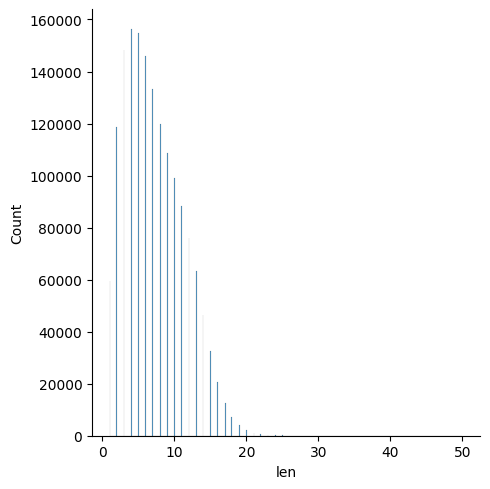

In [38]:
import seaborn as sns
sns.displot(df['len'])

In [39]:
df['len'].describe()

,len
count,1.600000e+06
mean,7.229460e+00
std,4.053380e+00
min,1.000000e+00
25%,4.000000e+00
50%,7.000000e+00
75%,1.000000e+01
max,5.000000e+01


# Tokenization and text to sequences

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [41]:
vocab_size = 70000
maxlen = 15
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data['text'])
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(train_data['text'])
training_padded = pad_sequences(training_sequences, padding="post", maxlen=maxlen, truncating="post")
test_sequences = tokenizer.texts_to_sequences(test_data['text'])
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

In [42]:
training_padded

array([[  13,    3,  297, ...,  902,    0,    0],
       [ 578,  333,  149, ...,    0,    0,    0],
       [  49,  418,   21, ...,    0,    0,    0],
       ...,
       [  48,   12,   36, ...,    0,    0,    0],
       [ 447,   33,  564, ..., 3814,  277,  385],
       [ 212,   28,  774, ...,    0,    0,    0]], dtype=int32)

# Label Encoder

In [43]:
train_data['sentiment']

,sentiment
1036873,positif
287781,negatif
333391,negatif
1484559,positif
562778,negatif
...,...
1592199,positif
880070,positif
1093760,positif
502113,negatif


In [44]:
from sklearn.preprocessing import LabelEncoder

In [45]:
encoder = LabelEncoder()
training_labels = encoder.fit_transform(train_data['sentiment'])

In [46]:
training_labels

array([1, 0, 0, ..., 1, 0, 1])

In [47]:
test_data.shape

(320000, 3)

In [48]:
test_labels = encoder.transform(test_data['sentiment'])

In [49]:
training_labels.shape

(1280000,)

In [50]:
training_labels = training_labels.reshape(-1, 1)
test_labels = test_labels.reshape(-1, 1)

In [51]:
test_labels.shape

(320000, 1)

# Modeling

In [52]:
import tensorflow as tf

In [53]:
import numpy as np

In [54]:
np.power(70000, 1/4)

np.float64(16.26576561697786)

In [56]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=2048,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
614/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7070 - loss: 0.6014

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7077 - loss: 0.6002 - val_accuracy: 0.7679 - val_loss: 0.4888
Epoch 2/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7749 - loss: 0.4793

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7749 - loss: 0.4792 - val_accuracy: 0.7743 - val_loss: 0.4761
Epoch 3/50
608/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7819 - loss: 0.4655

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7819 - loss: 0.4655 - val_accuracy: 0.7752 - val_loss: 0.4726
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7858 - loss: 0.4578 - val_accuracy: 0.7750 - val_loss: 0.4724
Epoch 5/50
612/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7895 - loss: 0.4508

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7895 - loss: 0.4508 - val_accuracy: 0.7760 - val_loss: 0.4702
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7907 - loss: 0.4466 - val_accuracy: 0.7750 - val_loss: 0.4704
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7931 - loss: 0.4416 - val_accuracy: 0.7751 - val_loss: 0.4708


In [57]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.grid()
    plt.show()

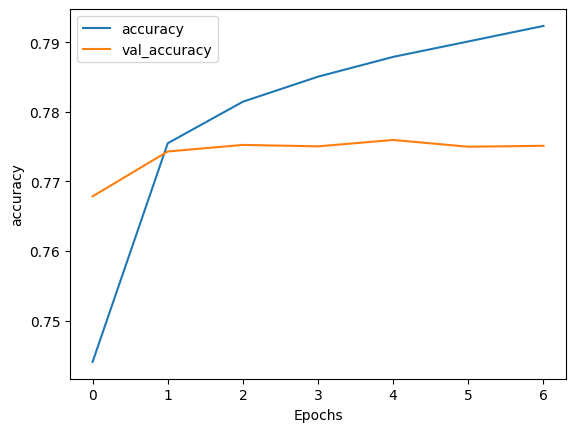

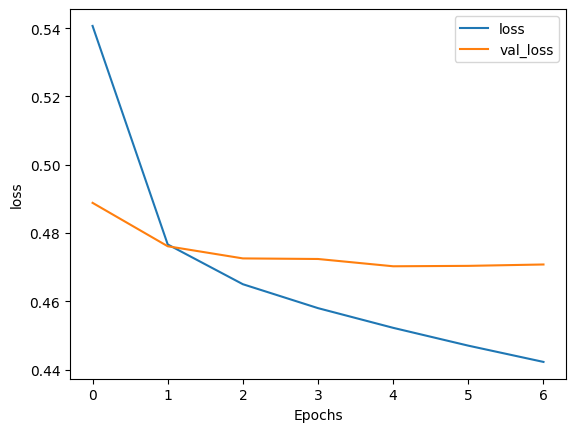

In [58]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Recurrent Neural Networks

In [59]:
# "J'étais content, maintenant je suis enervé"  negatif
# "J'étais enervé, maintenant je suis content"   positif

In [60]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.SimpleRNN(10),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

In [61]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=2048,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6897 - loss: 0.5747

625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6901 - loss: 0.5742 - val_accuracy: 0.7755 - val_loss: 0.4756
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7882 - loss: 0.4543

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7882 - loss: 0.4543 - val_accuracy: 0.7756 - val_loss: 0.4723
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7988 - loss: 0.4349 - val_accuracy: 0.7684 - val_loss: 0.4831
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8077 - loss: 0.4192 - val_accuracy: 0.7714 - val_loss: 0.4798
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8158 - loss: 0.4056 - val_accuracy: 0.7690 - val_loss: 0.4886
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8224 - loss: 0.3945 - val_accuracy: 0.7656 - val_loss: 0.4921
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8280 - loss: 0.3855 - val_accuracy: 0.7642 - val_loss: 0.4991
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8324 - loss: 0.3773 - val_accuracy: 0.7624 - val_loss: 0.5078
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8372 - loss: 0.3690 - val_accuracy: 0.7588 - val_

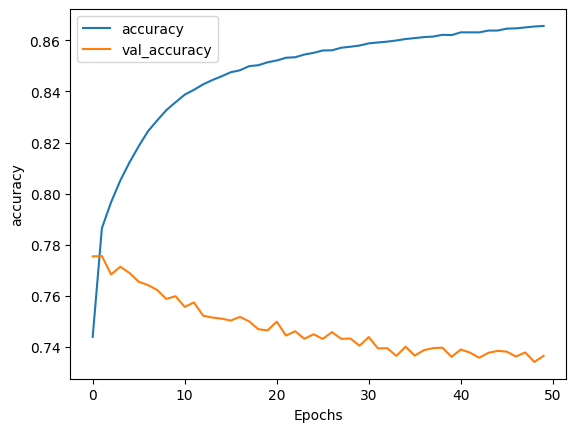

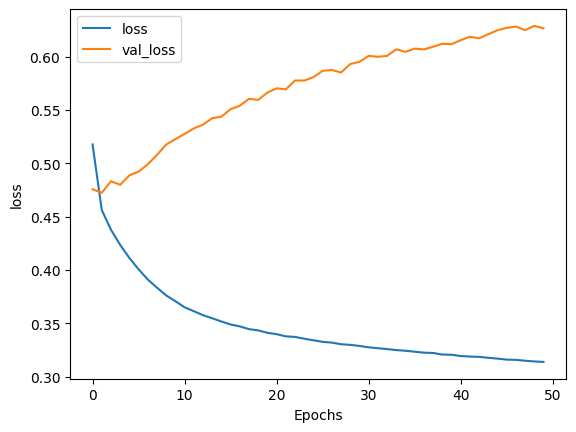

In [63]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# LSTM

In [64]:
# Je vis en , J'ai vécu dans différentes villes jusque-là, sauf la capital PARIS

In [65]:
adam = tf.keras.optimizers.Adam()

In [66]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16, return_sequences=True, dropout=0.25)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

In [67]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=2048,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7084 - loss: 0.5547

625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.7086 - loss: 0.5544 - val_accuracy: 0.7767 - val_loss: 0.4686
Epoch 2/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7834 - loss: 0.4589

625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7834 - loss: 0.4589 - val_accuracy: 0.7792 - val_loss: 0.4629
Epoch 3/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7912 - loss: 0.4444

625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7912 - loss: 0.4444 - val_accuracy: 0.7796 - val_loss: 0.4631
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7951 - loss: 0.4351 - val_accuracy: 0.7777 - val_loss: 0.4668
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7997 - loss: 0.4278 - val_accuracy: 0.7772 - val_loss: 0.4710
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8023 - loss: 0.4216 - val_accuracy: 0.7794 - val_loss: 0.4717
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8059 - loss: 0.4143 - val_accuracy: 0.7792 - val_loss: 0.4763
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8094 - loss: 0.4071 - val_accuracy: 0.7785 - val_loss: 0.4817
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8122 - loss: 0.4018 - val_accuracy: 0.7780 - val_loss: 0.4872
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8149 - loss: 0.3966 - val_accura

KeyboardInterrupt: 

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Transfert Learning

In [ ]:
glove_file = folder + "glove.6B.50d.txt"

In [ ]:
glove_file

In [ ]:
glove_embeddings = {}

In [ ]:
with open(glove_file) as f:
  for line in f:

    values = line.split(" ")
    word = values[0]
    vector = np.asarray(values[1:], dtype="float32")
    glove_embeddings[word] = vector


In [ ]:
glove_embeddings

In [ ]:
glove_embeddings['the']

In [ ]:
len(glove_embeddings)

In [ ]:
words = word_index.keys()

In [ ]:
i = 0
for word in words:
  if glove_embeddings.get(word) is not None:
    i = i + 1
print(i)

In [ ]:
len(words)

In [ ]:
embedding_matrix = np.zeros((vocab_size, 50))

In [ ]:
embedding_matrix.shape

In [ ]:
embedding_matrix[0]

In [ ]:
len(word_index)

In [ ]:
for word, i in word_index.items():
  if i > vocab_size -1:
    break
  embedding_vector = glove_embeddings.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector


In [ ]:
embedding_matrix[5]

In [ ]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, 50, weights=[embedding_matrix], trainable=False),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16, return_sequences=True, dropout=0.25)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

In [ ]:
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=2048,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")